In [1]:
import sqlite3

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
conn = sqlite3.connect("../data/db.ocgdb.db3")

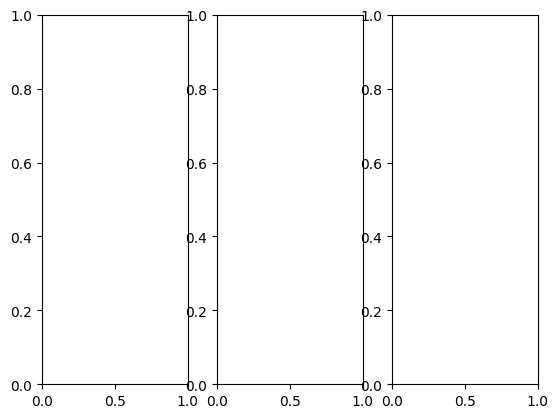

In [3]:
fig, axs = plt.subplots(1, 3)

In [4]:
cur = conn.cursor()
cur.execute("""
    SELECT Elo from Players
""")


In [5]:
elo = pd.DataFrame(cur.fetchall())
cur.close()
elo = elo.dropna()
elo = elo.astype("int32")
elo = elo[elo < 3000]
elo.head()

,0
1,1671.0
2,1608.0
3,1571.0
4,1914.0
5,1940.0


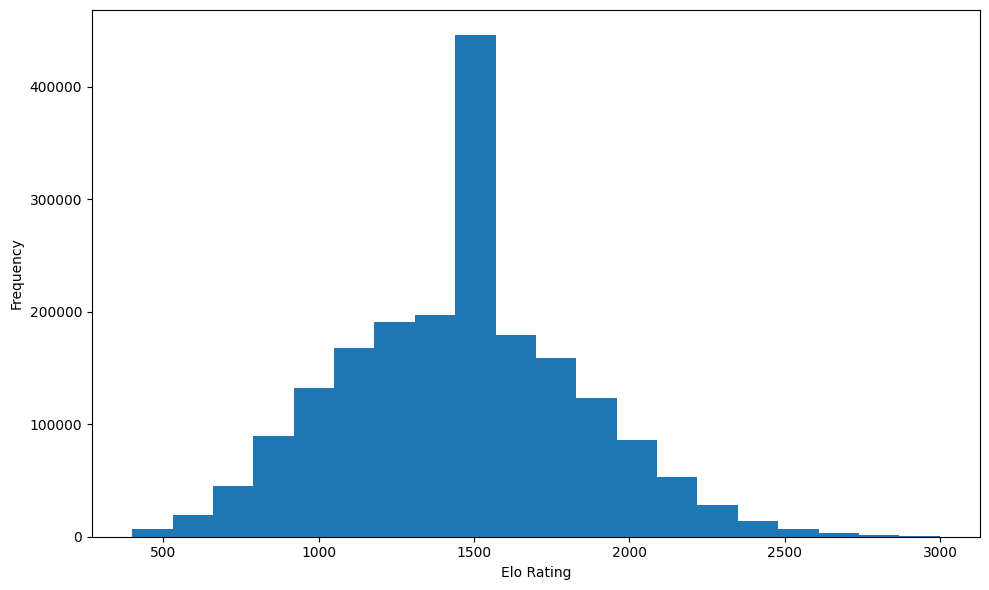

In [20]:
# Set colors
bar_color = "#523e32"  # Dark brown for bars
axis_color = "#816353"  # Lighter brown for axes

# Create figure with transparent background
plt.figure(figsize=(10, 6))
# plt.figure(figsize=(10, 6), facecolor="none")  # Outer background transparent
ax = plt.gca()
# ax.set_facecolor("none")  # Axes background transparent

# Remove top and right spines (borders)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.spines["bottom"].set_color(axis_color)  # Keep x-axis visible
# ax.spines["left"].set_color(axis_color)   # Keep y-axis visible

# Plot histogram (bars remain opaque)
# counts, bins, patches = ax.hist(elo, bins=20, color=bar_color, edgecolor="none")
counts, bins, patches = ax.hist(elo, bins=20)

# Customize y-axis to show "k" for thousands
# def format_thousands(x, pos):
#     return f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}"

# ax.yaxis.set_major_formatter(FuncFormatter(format_thousands))

# Customize ticks and labels (keep them visible)
# ax.tick_params(axis="both", colors=axis_color)
# ax.xaxis.label.set_color(axis_color)
# ax.yaxis.label.set_color(axis_color)

# Remove grid (or customize if needed)
# ax.grid(False)

# Optional: Add labels/title
# ax.set_xlabel("Elo Rating", color=axis_color)
# ax.set_ylabel("Frequency", color=axis_color)
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Frequency")
# ax.set_title("Distribution of Elo Ratings", color=axis_color, pad=20)

plt.savefig("elo.png")
plt.tight_layout()
plt.show()

In [15]:
cur = conn.cursor()
cur.execute("""
    WITH cp as(SELECT game_id, AVG(cp) as acpl, turn
                FROM evaluation_move_level
                WHERE mate is NULL
                GROUP BY game_id, turn)
            SELECT a.ID, CASE 
                WHEN b.turn = 0 THEN a.WhiteElo  
                WHEN b.turn = 1 THEN a.BlackElo
                END AS Elo, abs(acpl)
            FROM Games a INNER JOIN cp b
                ON a.ID = b.game_id
""")
cp = pd.DataFrame(cur.fetchall(), columns=["GAME", "ELO", "ACPL"])
cur.close()

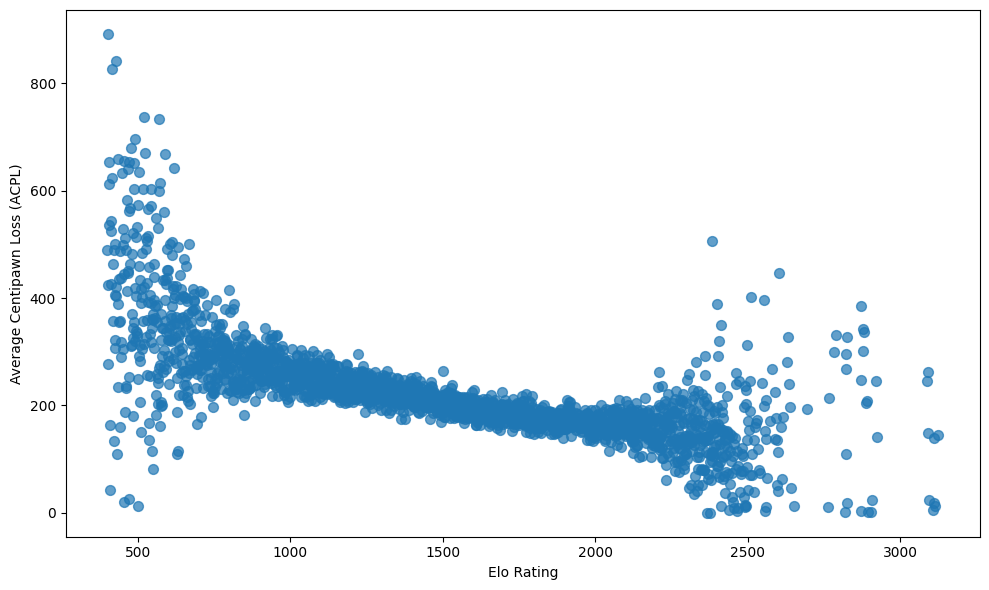

In [16]:
# Prepare data (assuming 'cp' is your DataFrame)
cp_new = cp[["ELO", "ACPL"]].groupby("ELO").mean().reset_index()

# Set colors
# point_color = "#523e32"  # Dark brown for points
# axis_color = "#816353"   # Light brown for axes

# Create figure with transparent background
plt.figure(figsize=(10, 6))
# plt.figure(figsize=(10, 6), facecolor="none")
ax = plt.gca()
# ax.set_facecolor("none")  # Transparent axes background

# Remove top and right spines (borders)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.spines["bottom"].set_color(axis_color)  # X-axis color
# ax.spines["left"].set_color(axis_color)    # Y-axis color

# Scatter plot (no line, just points)
ax.scatter(
    cp_new["ELO"], 
    cp_new["ACPL"], 
    # color=point_color, 
    alpha=0.7,   # Slight transparency for points
    s=50,        # Point size
    # edgecolor="none"  # No border on points
)

# Remove gridlines
ax.grid(False)

# Customize ticks and labels (matching axis color)
# ax.tick_params(axis="both", colors=axis_color)
# ax.set_xlabel("Elo Rating", color=axis_color)
# ax.set_ylabel("Average Centipawn Loss (ACPL)", color=axis_color)
ax.tick_params(axis="both" )
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Average Centipawn Loss (ACPL)")

# Optional: Format x-axis in thousands (e.g., 1500 → 1.5k)
# from matplotlib.ticker import FuncFormatter
# ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.1f}k" if x >= 1000 else f"{int(x)}"))

plt.savefig("scatter.svg", dpi = 300)
plt.tight_layout()
plt.show()

In [17]:
cur = conn.cursor()
cur.execute("""
    WITH cp as(SELECT game_id, AVG(winning_chance) as w,AVG(drawing_chance) as d,AVG(losing_chance) as l, turn
                FROM evaluation_move_level
                WHERE mate is NULL
                GROUP BY game_id, turn)
            SELECT a.ID, CASE 
                WHEN b.turn = 0 THEN a.WhiteElo 
                WHEN b.turn = 1 THEN a.BlackElo
                END AS Elo, 
                CASE 
                    WHEN b.turn = 0 THEN w
                    WHEN b.turn = 1 THEN l
                END AS w,
                CASE 
                    WHEN b.turn = 0 THEN l
                    WHEN b.turn = 1 THEN w
                END AS l,
                d
            FROM Games a INNER JOIN cp b
                ON a.ID = b.game_id
""")
wdl = pd.DataFrame(cur.fetchall(), columns=["GAME", "ELO", "winning_chance","losing_chance","drawing_chance"])
cur.close()

/tmp/ipykernel_4734/1335019520.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = wdl.groupby('ELO_bin')[['winning_chance', 'drawing_chance', 'losing_chance']].mean()


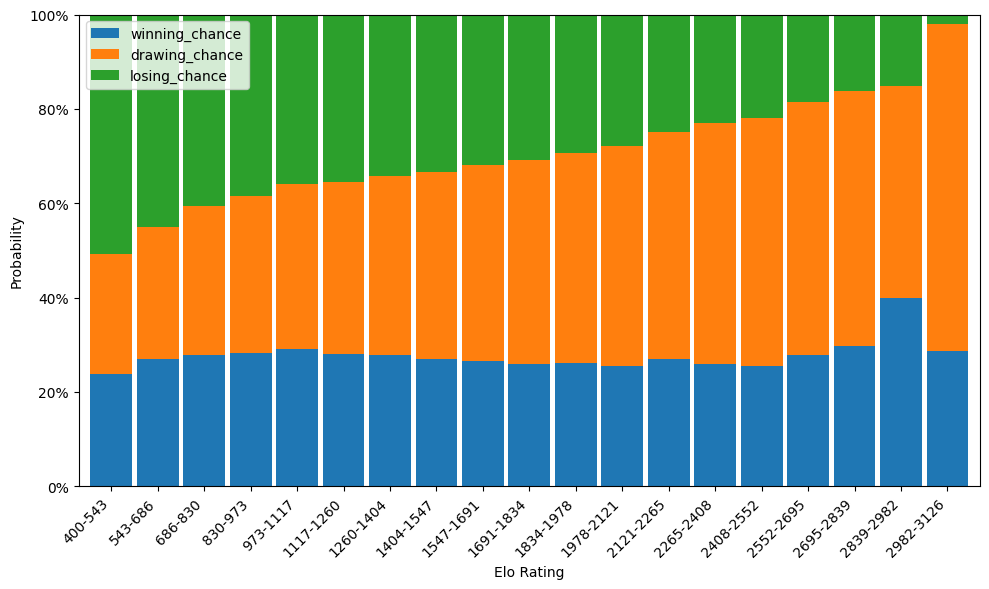

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np


# Create ELO bins (same as in your histogram example)
elo_bins = np.linspace(wdl['ELO'].min(), wdl['ELO'].max(), 20)
elo_labels = [f"{int(elo_bins[i])}-{int(elo_bins[i+1])}" for i in range(len(elo_bins)-1)]

# Bin the ELO data
wdl['ELO_bin'] = pd.cut(wdl['ELO'], bins=elo_bins, labels=elo_labels)

# Group by ELO bin and calculate mean probabilities
grouped = wdl.groupby('ELO_bin')[['winning_chance', 'drawing_chance', 'losing_chance']].mean()

# Create figure with transparent background
plt.figure(figsize=(10, 6))  # Outer background transparent
# plt.figure(figsize=(10, 6), facecolor="none")  # Outer background transparent
ax = plt.gca()
# ax.set_facecolor("none")  # Axes background transparent

# Remove top and right spines (borders)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.spines["bottom"].set_color(axis_color)  # Keep x-axis visible
# ax.spines["left"].set_color(axis_color)   # Keep y-axis visible

# Create stacked bar plot with earthy colors
colors = ['#719972', '#816353', '#523e32']  # Green, yellow, red shades
# grouped.plot(kind='bar', stacked=True, color=colors, width=0.9, ax=ax, edgecolor="none")
grouped.plot(kind='bar', stacked=True,  width=0.9, ax=ax)

# Customize y-axis to show percentages
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(y*100)}%"))

# Customize ticks and labels
ax.tick_params(axis="both")
# ax.tick_params(axis="both", colors=axis_color)
# ax.xaxis.label.set_color(axis_color)
# ax.yaxis.label.set_color(axis_color)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Set labels
ax.set_xlabel("Elo Rating")
ax.set_ylabel("Probability")
# ax.set_xlabel("Elo Rating", color=axis_color)
# ax.set_ylabel("Probability", color=axis_color)
# ax.get_legend().remove()

# Customize legend
# legend = ax.legend(title='Outcome', 
#                   labels=['Winning', 'Drawing', 'Losing'],
#                   facecolor=bar_color, 
#                   edgecolor=axis_color,
#                   bbox_to_anchor=(1.02, 1),
#                   loc='upper left')
# plt.setp(legend.get_texts(), color='white')
# legend.get_title().set_color('white')

# Remove grid
ax.grid(False)

plt.savefig("stacked.svg",  dpi=300)
plt.tight_layout()
plt.show()